In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
# Read all the words

words = open('names.txt', 'r').read().splitlines()
words[:8]

['frazier',
 'miller',
 'gilbert',
 'ward',
 'arnold',
 'saunders',
 'mcdaniel',
 'collins']

In [4]:
len(words)

46654

In [5]:
# Build the vocalbulory of characters and mappings to/from integers

chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s, i in stoi.items()}
print(itos) 

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


Build the dataset


In [ ]:
# Build the dataset

block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y = [], [] # X are the input and Y are the labels for each example inside X
for w in words:

    #print(w)
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        #print(''.join(itos[i] for i in context), '------->', itos[ix])
        context = context[1:] + [ix] # crop and append

X = torch.tensor(X)
Y = torch.tensor(Y)


In [ ]:
X.shape, X.dtype, Y.shape, Y.dtype

----

In [6]:
# Build the dataset
def build_dataset(words):
    block_size = 3  # Context length: how many characters do we take to predict the next one?
    X, Y = [], []  # X are the inputs and Y are the labels for each example inside X
    for w in words:

        # print(w)
        context = [0] * block_size  # Initialize context with padding
        for ch in w + '.':  # Append '.' to mark the end of the word
            ix = stoi[ch]  # Convert character to index
            X.append(context)  # Add context to inputs
            Y.append(ix)  # Add index to labels
            context = context[1:] + [ix]  # Update context by cropping and appending

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)  # Corrected typo
    return X, Y

# Shuffle words and split into train, dev, and test sets
import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))  # 80% for training
n2 = int(0.9 * len(words))  # 10% for validation, 10% for testing

Xtr, Ytr = build_dataset(words[:n1])  # Training set
Xdev, Ydev = build_dataset(words[n1:n2])  # Validation set
Xte, Yte = build_dataset(words[n2:])  # Test set


torch.Size([264137, 3]) torch.Size([264137])
torch.Size([32804, 3]) torch.Size([32804])
torch.Size([32993, 3]) torch.Size([32993])


In [ ]:
C = torch.randn(27, 2)

In [ ]:
emd = C[X]
emd.shape

In [ ]:
W1 = torch.randn(6, 100)
b1 = torch.randn(100)

In [ ]:
# torch.cat([emd[:, 0, :], emd[:, 1, :], emd[:, 2, :]], 1).shape 

# this can't be change with changing block_size

In [ ]:
# torch.cat(torch.unbind(emd,1), 1).shape # another way to do it

In [ ]:
h = torch.tanh(emd.view(-1, 6) @ W1 + b1)

In [ ]:
h.shape

In [ ]:
W2 = torch.randn(100, 27)
b2 = torch.randn(27)

In [ ]:
logits = h @ W2 + b2

In [ ]:
logits.shape

In [ ]:
counts = logits.exp()

In [ ]:
probs = counts / counts.sum(1, keepdim=True)

In [ ]:
probs.shape

In [ ]:
probs[0].sum()

In [ ]:
loss = -probs[torch.arange(35), Y].log().mean()
loss

---

*organised code*

In [29]:
Xtr.shape, Ytr.shape #dataset

(torch.Size([264137, 3]), torch.Size([264137]))

In [55]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn((200), generator=g) 
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [56]:
sum(p.nelement() for p in parameters) # numbers of parameter intotal)

11897

In [57]:
"""
# forward pass

emd = C[X] # (32, 3, 2)
h = torch.tanh(emd.view(-1, 6) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)

# counts = logits.exp()
# probs = counts / counts.sum(1, keepdim=True)
#loss = -probs[torch.arange(35), Y].log().mean()

# ⬆⬆⬆ this can be replaced by ⬇⬇⬇ ---> F.cross_entropy(logits, Y)

loss = F.cross_entropy(logits, Y)
loss

"""

'\n# forward pass\n\nemd = C[X] # (32, 3, 2)\nh = torch.tanh(emd.view(-1, 6) @ W1 + b1) # (32, 100)\nlogits = h @ W2 + b2 # (32, 27)\n\n# counts = logits.exp()\n# probs = counts / counts.sum(1, keepdim=True)\n#loss = -probs[torch.arange(35), Y].log().mean()\n\n# ⬆⬆⬆ this can be replaced by ⬇⬇⬇ ---> F.cross_entropy(logits, Y)\n\nloss = F.cross_entropy(logits, Y)\nloss\n\n'

### CrossEntropyLoss in PyTorch

#### torch.nn.functional.cross_entropy(input, target, weight=None, size_average=None, ignore_index=-100, reduce=None, reduction='mean', label_smoothing=0.0)[source]
#### Compute the cross entropy loss between input logits and target.


*Advantages*
- PyTorch cluster up all the operations and makes fused kernal that very effiently evalue this operations.
- Backaward can be much more efficent (not just cuz of its fused kernal), but analytically and mathematically its often much simpler backward pass.
- Under the hood, F.cross_entropy can also be significantly more numerically well-behaved; we cannot pass very large logits throught the manual expression.



In [58]:
for p in parameters:
    p.requires_grad = True

In [59]:
#lerrning rates

lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [60]:
lri = []
lossi = []
stepi = []

In [73]:
for i in range(200000):

    # mini-batch construct
    ix = torch.randint(0, Xtr.shape[0], (32,))

    #forward pass
    emd = C[Xtr[ix]] # (32, 3, 2)
    h = torch.tanh(emd.view(-1, 30) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)
    loss = F.cross_entropy(logits, Ytr[ix])
    #print(loss.item())

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    # lr = lrs[i]
    lr = 0.1 if i < 100000 else 0.01 # learning rate schedule
    for p in parameters:
        p.data += -lr * p.grad 

    # track stats
    #lri.append(lre[i])
    stepi.append(i)
    lossi.append(loss.log10().item())

#print(loss.item())



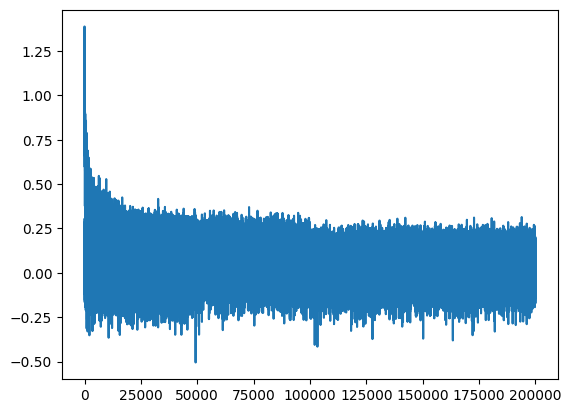

In [76]:
plt.plot(stepi, lossi)

In [74]:
emd = C[Xdev] # (32, 3, 2)
h = torch.tanh(emd.view(-1, 30) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (3 2, 27)
loss = F.cross_entropy(logits, Ydev) # (32, 27)
loss

tensor(1.1661, grad_fn=<NllLossBackward0>)

In [75]:
emd = C[Xtr] # (32, 3, 2)
h = torch.tanh(emd.view(-1, 30) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ytr) # (32, 27)
loss

tensor(1.1460, grad_fn=<NllLossBackward0>)

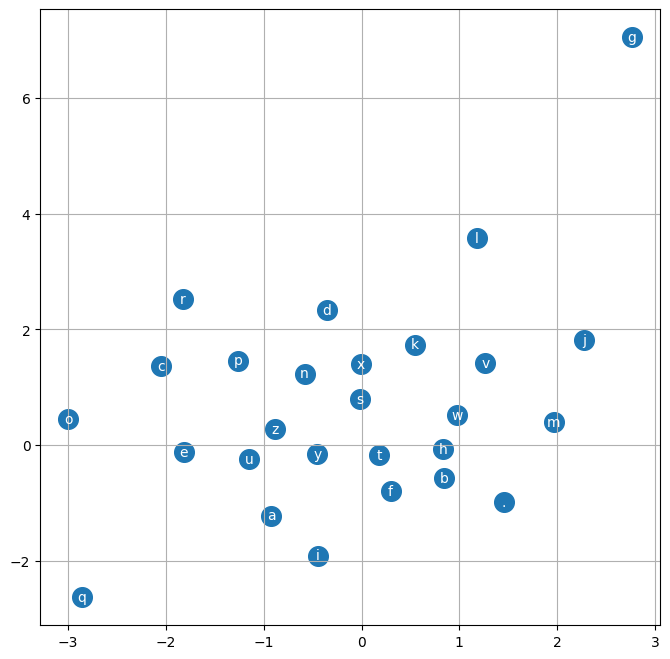

In [54]:
plt.figure(figsize=(8, 8))
plt.scatter(C[:, 0].data, C[:,1].data, s=200) 
for i in range(C.shape[0]):
    plt.text(C[i, 0].item(), C[i, 1].item(), itos[i], ha='center', va='center', color='white')
plt.grid('minor')

In [ ]:
# training split, dev/validation split, # test split
# 80% train, 10% dev, 10% test
# train to fit the model or train the parameters, dev to tune hyperparameters, test to evaluate the performance of the model at the end


# Evaluating loss on the test split very often is not a good idea, because the model can overfit to the test set.
# Another thing is if every single time we evaluate the model, we are using the test set to train the model, so the model is not generalizing well to unseen data.

sampling

In [ ]:
block_size = 3 # context length

In [81]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10) # for reproducibility

for _ in range(20):

    out =[]
    context = [0] * block_size # context length
    while True:
        # forward pass
        emd = C[torch.tensor([context])] # (1, block_size, d) - Embedding lookup for the current context.
        h = torch.tanh(emd.view(1,-1) @ W1 + b1) # Hidden layer computation with tanh activation.
        logits = h @ W2 + b2 # Output layer to compute logits.
        probs = F.softmax(logits, dim=1) # Converts logits to probabilities using softmax.

        # sample from the distribution
        ix = torch.multinomial(probs, num_samples=1, generator=g).item() # samples the next character index (ix) from the probability distribution.
        context = context[1:] + [ix]
        out.append(ix)
        
        if ix == 0:
            break

    print(''.join(itos[i] for i in out)) # convert to string

mora.
mons.
herrez.
durham.
reyers.
brown.
gravera.
melton.
milton.
mitcheco.
barner.
bishop.
pon.
shernandez.
jeffernanderson.
gonzalez.
mayes.
ruiz.
lewis.
hugh.
